# 단계 3 — WoE(증거가중치) · IV(정보가치)

신용평가 모형에서 쓰는 두 도구를 **직접 구현**해서, 어떤 특징이 사기 판별에
쓸모 있는지 순위를 매깁니다.

---

## WoE 란? (Weight of Evidence, 증거가중치)

특징 하나를 몇 개의 **구간(bin)** 으로 나눈 뒤, 각 구간이 얼마나 "사기 쪽 냄새"가
나는지를 숫자 하나로 바꾼 값입니다.

$$
\mathrm{WoE}_i = \ln\!\left( \frac{\text{사기}_i / \text{사기}_{\text{전체}}}{\text{정상}_i / \text{정상}_{\text{전체}}} \right)
$$

**기호 뜻**

| 기호 | 읽는 법 | 뜻 |
|---|---|---|
| $i$ | 아이 | 구간 번호. 예: "보낸 거래 0~2회" 구간 |
| $\text{사기}_i$ | 사기 아이 | $i$ 구간 안에 있는 **사기 주소 개수** |
| $\text{사기}_{\text{전체}}$ | 사기 전체 | 데이터 전체의 사기 주소 개수 (2,179) |
| $\text{정상}_i$ | 정상 아이 | $i$ 구간 안에 있는 **정상 주소 개수** |
| $\text{정상}_{\text{전체}}$ | 정상 전체 | 데이터 전체의 정상 주소 개수 (7,662) |
| $\ln$ | 자연로그 | 밑이 $e \approx 2.718$ 인 로그 |

**읽는 법**

- $\mathrm{WoE} > 0$ → 이 구간엔 사기가 **평균보다 많이** 모여 있다 (위험 신호)
- $\mathrm{WoE} = 0$ → 전체 평균과 같다 (정보 없음)
- $\mathrm{WoE} < 0$ → 정상이 평균보다 많이 모여 있다 (안전 신호)

> **비유**: 반 평균이 70점인데 어떤 문제를 맞힌 학생들의 평균이 90점이면,
> "그 문제를 맞혔다"는 사실은 실력의 **증거**가 됩니다. WoE 는 그 증거의 세기예요.

> ⚠️ **부호 규약**: 전통적인 신용평가 교과서는 $\ln(\text{정상}/\text{사기})$ 로 정의해
> 값이 클수록 '우량'을 뜻합니다. 이 프로젝트는 사기 탐지에 맞춰 **반대 부호**를 씁니다
> (클수록 위험). 부호만 뒤집힌 것이라 IV 값과 모델 성능은 규약과 무관하게 같습니다.

---

## IV 란? (Information Value, 정보가치)

WoE 는 구간 하나의 증거 세기입니다. 이걸 특징 전체에 대해 합쳐서
"이 특징이 얼마나 유용한가"를 **숫자 하나**로 요약한 것이 IV 입니다.

$$
\mathrm{IV} = \sum_i \left( \frac{\text{사기}_i}{\text{사기}_{\text{전체}}} - \frac{\text{정상}_i}{\text{정상}_{\text{전체}}} \right) \times \mathrm{WoE}_i
$$

**기호 뜻**

| 기호 | 뜻 |
|---|---|
| $\sum_i$ | 시그마. "모든 구간 $i$ 에 대해 더하라" |
| 앞 괄호 | 두 집단의 **비중 차이** — 이 구간에 사기가 정상보다 얼마나 더 몰렸나 |
| $\mathrm{WoE}_i$ | 그 구간의 **증거 세기** |

즉 **(비중 차이) × (증거 세기)** 를 모든 구간에서 더한 값입니다.
차이도 크고 증거도 센 구간이 많을수록 IV 가 커집니다. IV 는 항상 0 이상입니다.

**해석 기준** (신용평가 실무의 Siddiqi 기준)

| IV 범위 | 해석 |
|---|---|
| < 0.02 | 거의 쓸모없음 |
| 0.02 ~ 0.1 | 약함 |
| 0.1 ~ 0.3 | 중간 |
| 0.3 ~ 0.5 | 강함 |
| **> 0.5** | 매우 강함 — **데이터 누수를 의심해야 함** |

마지막 줄이 이 프로젝트에서 특히 중요합니다. IV 가 비정상적으로 높으면
실력이 아니라 **정답이 새어 들어온 것**일 수 있습니다.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, preprocessing
from src.woe_iv import WeightOfEvidenceEncoder, interpret_information_value
from src.plot_style import apply_project_plot_style, COLOR_NORMAL, COLOR_FRAUD, COLOR_TEXT_SECONDARY

apply_project_plot_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
config.ensure_directories_exist()
print("준비 완료")

준비 완료


---

## 1. 두 벌의 데이터 준비

단계 2에서 찾은 데이터 누수 때문에 **두 가지 데이터**를 만들어 나란히 비교합니다.

| 트랙 | 내용 | 특징 수 |
|---|---|---|
| **full** | 누수를 그대로 둠. `ERC20 이력 없음(표시)` 열을 특징으로 포함 | 39 |
| **no_leak** | 표시 열 없음. ERC20 결측을 0으로 채워 누수 통로를 막음 | 38 |

공통 정리: 중복 주소 25행 제거, 상수 열 7개 제거, 식별자 3개 제거, 문자열 열 2개 제거

In [2]:
# 두 트랙의 데이터를 각각 만든다
features_full, target_full, log_full = preprocessing.build_modeling_dataset(
    preprocessing.TRACK_FULL
)
features_no_leak, target_no_leak, log_no_leak = preprocessing.build_modeling_dataset(
    preprocessing.TRACK_NO_LEAK
)

comparison = pd.DataFrame([log_full, log_no_leak]).set_index("트랙").T
comparison

트랙,full,no_leak
시작 행 수,9841,9841
중복 주소 제거,25,25
상수 열 제거,7,7
문자열 열 제거,2,2
0으로 채운 칸 수,13264,13264
누수 표시 열,포함,제외
최종 행 수,9816,9816
최종 특징 수,39,38
사기 비율(%),22.2,22.2


In [3]:
# '최소 제거' 후에도 남아 있는 누수 위험을 확인한다.
# 완전히 정직하게 보고하기 위해 반드시 짚고 넘어가야 하는 부분이다.
residual_full = preprocessing.describe_residual_leakage(features_full, target_full)
residual_no_leak = preprocessing.describe_residual_leakage(features_no_leak, target_no_leak)

print("[full 트랙] 모든 특징이 0인 행")
print(residual_full.to_string(index=False))
print()
print("[no_leak 트랙] 모든 특징이 0인 행")
print(residual_no_leak.to_string(index=False))

[full 트랙] 모든 특징이 0인 행
         구분  행 수  사기 수  사기 비율(%)
모든 특징이 0인 행    0     0       NaN
      그 외 행 9816  2179      22.2

[no_leak 트랙] 모든 특징이 0인 행
         구분  행 수  사기 수  사기 비율(%)
모든 특징이 0인 행  274   274     100.0
      그 외 행 9542  1905      20.0


### 잔여 위험 — 솔직하게 기록해 둡니다

'최소 제거'는 **가장 큰 누수 통로를 막았지만, 완전히 없애지는 못했습니다.**

| | 조치 전 | no_leak 트랙 |
|---|---|---|
| 정답이 100% 또는 0%로 갈리는 행 | 5,228행 (53.1%) | **274행 (2.8%)** |

남은 274행은 **모든 특징 값이 0인 '껍데기 행'** 이고, 전부 사기입니다.
모델이 "값이 전부 0이면 사기"라는 규칙을 외울 수 있으므로,
no_leak 트랙의 성능도 **약간은 낙관적**이라고 봐야 합니다.
단계 5의 SHAP 분석에서 모델이 실제로 이 규칙에 의존하는지 확인하겠습니다.

---

## 2. IV 계산 — 어떤 특징이 쓸모 있는가

여기서는 특징 선별이 목적이므로 **전체 데이터로 IV 를 계산**합니다.
다만 단계 4의 모델 학습에서는 반드시 **학습 fold 로만 WoE 를 fit** 해야 합니다.
WoE 계산에는 정답이 들어가기 때문에, 전체로 fit 하면 검증셋의 정답이 새어 들어갑니다.

문자열 열 2개(`ERC20 most sent token type`, `ERC20_most_rec_token_type`)는
모델 입력에서는 뺐지만, **얼마나 유용했을지 확인하려고 IV 계산에는 포함**합니다.

In [4]:
# IV 계산용 데이터: 문자열 열까지 포함시킨다
features_for_iv, target_for_iv, _ = preprocessing.build_modeling_dataset(
    preprocessing.TRACK_FULL, include_string_features=True
)
print(f"IV 계산 대상: {features_for_iv.shape[1]}개 특징 (문자열 2개 포함)")

# 인코더를 만들어 학습시킨다.
#   max_bin_count=10       : 최대 10구간
#   separate_zero_bin=True : 값이 0인 행을 별도 구간으로 분리
#                            (이 데이터는 0이 몰려 있는 열이 많아 이 옵션이 중요하다)
woe_encoder_full = WeightOfEvidenceEncoder(max_bin_count=10, separate_zero_bin=True)
woe_encoder_full.fit(features_for_iv, target_for_iv)

iv_ranking_full = woe_encoder_full.get_information_value_ranking()
print(f"계산 완료: {len(iv_ranking_full)}개 특징")

IV 계산 대상: 41개 특징 (문자열 2개 포함)


계산 완료: 41개 특징


In [5]:
# ── IV 상위 15개 (full 트랙: 누수 포함) ─────────────────────────────
iv_top15_full = iv_ranking_full.head(15).copy()
iv_top15_full["IV"] = iv_top15_full["IV"].round(4)
iv_top15_full

,순위,특징,IV,해석,구간 수
0,1,ERC20_most_rec_token_type,9.6459,매우 강함 (누수 의심),10
1,2,ERC20 most sent token type,9.6285,매우 강함 (누수 의심),8
2,3,ERC20 이력 없음(표시),3.4797,매우 강함 (누수 의심),2
3,4,total ether received,2.9779,매우 강함 (누수 의심),11
4,5,Time Diff between first and last (Mins),2.8842,매우 강함 (누수 의심),11
5,6,avg val received,2.6622,매우 강함 (누수 의심),11
6,7,total transactions (including tnx to create contract,2.5465,매우 강함 (누수 의심),10
7,8,max value received,2.0936,매우 강함 (누수 의심),11
8,9,Received Tnx,1.7667,매우 강함 (누수 의심),9
9,10,Unique Received From Addresses,1.7170,매우 강함 (누수 의심),7


In [6]:
# ── no_leak 트랙의 IV 도 계산해서 비교 ──────────────────────────────
features_no_leak_iv, target_no_leak_iv, _ = preprocessing.build_modeling_dataset(
    preprocessing.TRACK_NO_LEAK, include_string_features=True
)

woe_encoder_no_leak = WeightOfEvidenceEncoder(max_bin_count=10, separate_zero_bin=True)
woe_encoder_no_leak.fit(features_no_leak_iv, target_no_leak_iv)

iv_ranking_no_leak = woe_encoder_no_leak.get_information_value_ranking()
iv_top15_no_leak = iv_ranking_no_leak.head(15).copy()
iv_top15_no_leak["IV"] = iv_top15_no_leak["IV"].round(4)
iv_top15_no_leak

,순위,특징,IV,해석,구간 수
0,1,ERC20_most_rec_token_type,9.6459,매우 강함 (누수 의심),10
1,2,ERC20 most sent token type,9.6285,매우 강함 (누수 의심),8
2,3,total ether received,2.9779,매우 강함 (누수 의심),11
3,4,Time Diff between first and last (Mins),2.8842,매우 강함 (누수 의심),11
4,5,avg val received,2.6622,매우 강함 (누수 의심),11
5,6,total transactions (including tnx to create contract,2.5465,매우 강함 (누수 의심),10
6,7,max value received,2.0936,매우 강함 (누수 의심),11
7,8,Received Tnx,1.7667,매우 강함 (누수 의심),9
8,9,Unique Received From Addresses,1.7170,매우 강함 (누수 의심),7
9,10,min value received,1.6080,매우 강함 (누수 의심),11


### 🚨 여기서 멈춰서 봐야 할 것 — **41개 특징이 전부 IV > 0.5**

위 두 표를 보면 이상한 점이 있습니다. **모든 특징의 해석이 "매우 강함 (누수 의심)"** 입니다.

실제 신용평가 실무에서는 IV 0.3만 넘어도 아주 좋은 변수 취급을 받고,
IV 1.0을 넘는 변수는 **거의 예외 없이 데이터 문제를 의심**합니다.
그런데 여기서는 41개 중 15개가 IV 1.0을 넘고, 1·2위는 **9.6** 입니다.

이것은 "이 데이터가 굉장히 좋다"는 뜻이 아니라
**"데이터 전체가 오염됐다"** 는 뜻입니다. 아래에서 오염 경로를 하나씩 찾아보겠습니다.

---

## 3-B. 오염 경로 카탈로그 — 어디서 정답이 새는가

단계 2에서 찾은 것 말고도 새는 곳이 더 있는지 체계적으로 찾습니다.

**찾는 방법**: 어떤 구간에 **30건 이상**이 들어 있는데 그 구간의 사기 비율이
**정확히 0% 또는 100%** 라면, 그건 예측이 아니라 정답이 새는 통로입니다.

In [7]:
# 두 트랙의 IV 차이를 먼저 확인한다
iv_side_by_side = (
    iv_ranking_full[["특징", "IV"]].rename(columns={"IV": "IV (full)"})
    .merge(
        iv_ranking_no_leak[["특징", "IV"]].rename(columns={"IV": "IV (no_leak)"}),
        on="특징", how="outer",
    )
)
iv_side_by_side["차이"] = iv_side_by_side["IV (full)"] - iv_side_by_side["IV (no_leak)"]

changed = iv_side_by_side[iv_side_by_side["차이"].abs() > 1e-9]
print(f"두 트랙 사이에 IV 가 달라진 특징: {len(changed)}개")
print(changed.round(4).to_string(index=False) if len(changed) else "(없음)")
print()
print("→ no_leak 트랙은 '표시 열'만 뺐을 뿐, 나머지 특징의 계산은 똑같습니다.")
print("  따라서 나머지 IV 가 같은 것은 정상입니다.")
print("  두 트랙의 진짜 차이는 단계 4의 '모델 성능'에서 드러납니다.")

두 트랙 사이에 IV 가 달라진 특징: 0개
(없음)

→ no_leak 트랙은 '표시 열'만 뺐을 뿐, 나머지 특징의 계산은 똑같습니다.
  따라서 나머지 IV 가 같은 것은 정상입니다.
  두 트랙의 진짜 차이는 단계 4의 '모델 성능'에서 드러납니다.


In [8]:
# ── 오염 경로 찾기: '완벽하게 갈리는 구간' 전수 조사 ────────────────
MINIMUM_BIN_SIZE = 30   # 이보다 작은 구간은 우연일 수 있으므로 제외

def find_perfectly_separating_bins(encoder, minimum_bin_size=MINIMUM_BIN_SIZE):
    """사기 비율이 정확히 0% 또는 100% 인 큰 구간을 모두 찾아 표로 돌려준다."""
    found_rows = []
    for feature_name, table in encoder.binning_tables_.items():
        for _, bin_row in table.iterrows():
            is_perfect = bin_row["사기 비율"] in (0.0, 1.0)
            if is_perfect and bin_row["건수"] >= minimum_bin_size:
                found_rows.append({
                    "특징": feature_name,
                    "구간": str(bin_row["bin"]),
                    "건수": int(bin_row["건수"]),
                    "사기 비율(%)": round(bin_row["사기 비율"] * 100, 1),
                    "IV 기여": round(bin_row["IV 기여"], 3),
                })
    result = pd.DataFrame(found_rows)
    if len(result):
        result = result.sort_values("IV 기여", ascending=False).reset_index(drop=True)
    return result

perfect_bins = find_perfectly_separating_bins(woe_encoder_no_leak)
print(f"정답이 완벽하게 갈리는 구간: {len(perfect_bins)}개 (건수 {MINIMUM_BIN_SIZE} 이상)\n")
perfect_bins.head(20)

정답이 완벽하게 갈리는 구간: 10개 (건수 30 이상)



,특징,구간,건수,사기 비율(%),IV 기여
0,ERC20 most sent token type,,1191,100.0,4.927
1,ERC20 most sent token type,0,4388,0.0,4.494
2,ERC20_most_rec_token_type,0,4388,0.0,4.493
3,ERC20_most_rec_token_type,Blockwell say NOTSAFU,779,100.0,3.070
4,total transactions (including tnx to create contract,0,529,100.0,1.992
5,total ether received,"(100.695, 101.0]",1475,0.0,1.299
6,min value received,"(23.67, 101.0]",1197,0.0,1.022
7,avg val received,"(50.5, 101.0]",944,0.0,0.776
8,total Ether sent,"(100.998, 100.999]",465,0.0,0.339
9,ERC20 min val sent,"(0.01, 0.62]",76,0.0,0.037


In [9]:
# ── 오염 경로 2: 같은 값이 비정상적으로 반복되는가? ─────────────────
# 진짜 블록체인 거래라면 금액이 소수점까지 제각각이어야 정상이다.
# 수백 개 주소가 '정확히 같은 금액'을 가졌다면 인위적으로 만들어진 데이터일 수 있다.

from src import data_loader
raw_dataframe = data_loader.load_raw_dataset()

repeated_value_rows = []
for feature_name in ["total ether received", "total Ether sent", "avg val received", "max value received"]:
    value_counts = raw_dataframe[feature_name].value_counts().head(3)
    for repeated_value, occurrence_count in value_counts.items():
        matching_rows = raw_dataframe[raw_dataframe[feature_name] == repeated_value]
        repeated_value_rows.append({
            "특징": feature_name,
            "반복된 값": repeated_value,
            "반복 횟수": int(occurrence_count),
            "사기 비율(%)": round(float(matching_rows["FLAG"].mean()) * 100, 1),
        })

repeated_values_table = pd.DataFrame(repeated_value_rows)
repeated_values_table

,특징,반복된 값,반복 횟수,사기 비율(%)
0,total ether received,101.000000,1476,0.0
1,total ether received,0.000000,707,92.9
2,total ether received,2001.000000,342,0.0
3,total Ether sent,0.000000,2067,40.2
4,total Ether sent,100.999016,454,0.0
5,total Ether sent,100.998446,384,0.0
6,avg val received,101.000000,765,0.0
7,avg val received,0.000000,709,92.7
8,avg val received,50.500000,639,0.0
9,max value received,101.000000,766,0.0


In [10]:
# ── 오염 경로 3: 껍데기 행(모든 특징이 0)을 빼면 IV 가 얼마나 내려가나? ──
# 공정한 비교를 위해 '같은 38개 특징'으로 두 번 계산한다.
# (앞의 woe_encoder_no_leak 은 문자열 2개를 포함한 40개짜리라 그대로 비교하면 안 된다)
all_zero_mask = (features_no_leak == 0).all(axis=1)

encoder_with_empty_rows = WeightOfEvidenceEncoder(max_bin_count=10, separate_zero_bin=True)
encoder_with_empty_rows.fit(features_no_leak, target_no_leak)

features_without_empty = features_no_leak[~all_zero_mask].reset_index(drop=True)
target_without_empty = target_no_leak[~all_zero_mask].reset_index(drop=True)

encoder_without_empty_rows = WeightOfEvidenceEncoder(max_bin_count=10, separate_zero_bin=True)
encoder_without_empty_rows.fit(features_without_empty, target_without_empty)

iv_effect_of_empty_rows = pd.DataFrame({
    "특징": list(encoder_with_empty_rows.information_values_.keys()),
    "IV (껍데기 행 포함)": list(encoder_with_empty_rows.information_values_.values()),
    "IV (껍데기 행 제외)": [
        encoder_without_empty_rows.information_values_[name]
        for name in encoder_with_empty_rows.information_values_
    ],
})
iv_effect_of_empty_rows["감소량"] = (
    iv_effect_of_empty_rows["IV (껍데기 행 포함)"] - iv_effect_of_empty_rows["IV (껍데기 행 제외)"]
)
iv_effect_of_empty_rows = iv_effect_of_empty_rows.sort_values(
    "IV (껍데기 행 포함)", ascending=False
).reset_index(drop=True)

iv_over_half_before = sum(v > 0.5 for v in encoder_with_empty_rows.information_values_.values())
iv_over_half_after = sum(v > 0.5 for v in encoder_without_empty_rows.information_values_.values())

print(f"모델에 실제로 쓰는 특징 {features_no_leak.shape[1]}개 기준")
print(f"껍데기 행 {int(all_zero_mask.sum())}개를 빼면:")
print(f"  IV > 0.5 인 특징 수: {iv_over_half_before}개 -> {iv_over_half_after}개")
print()
iv_effect_of_empty_rows.head(12).round(3)

모델에 실제로 쓰는 특징 38개 기준
껍데기 행 274개를 빼면:
  IV > 0.5 인 특징 수: 23개 -> 21개



,특징,IV (껍데기 행 포함),IV (껍데기 행 제외),감소량
0,total ether received,2.978,1.510,1.468
1,Time Diff between first and last (Mins),2.884,1.848,1.036
2,avg val received,2.662,1.855,0.807
3,total transactions (including tnx to create contract,2.546,0.727,1.820
4,max value received,2.094,1.248,0.845
5,Received Tnx,1.767,0.455,1.312
6,Unique Received From Addresses,1.717,0.353,1.364
7,min value received,1.608,1.503,0.105
8,total ether balance,1.515,0.706,0.809
9,ERC20 min val rec,1.397,1.637,-0.240


### 오염 경로 정리 — 이 데이터에서 정답이 새는 곳은 최소 4군데

| # | 경로 | 규모 | 조치 |
|---|---|---|---|
| 1 | **ERC20 결측** — 비어 있으면 100% 사기 | 829행 | 0으로 채워 차단 (no_leak 트랙) |
| 2 | **껍데기 행** — 모든 특징이 0이면 100% 사기 | 274행 | 남아 있음 (단계 4에서 영향 확인) |
| 3 | **토큰 이름** — `Blockwell say NOTSAFU` 등 특정 토큰명이 100% 사기 | 779행 + 1,191행 | 문자열 열을 모델에서 제외해 차단 |
| 4 | **반복 금액** — `total ether received = 101.0` 은 100% 정상 | 1,476행 | 남아 있음 |

**4번이 특히 심각합니다.** 진짜 블록체인 거래라면 금액이 소수점까지 제각각이어야 하는데,
1,476개 주소가 **정확히 101.0 ETH** 를 받았고 그중 사기는 0건입니다.
정상 주소 집단의 상당수가 **인위적으로 만들어졌거나 특정 조건으로 걸러 모은 것**으로 보입니다.

> 저는 이 데이터가 어떻게 만들어졌는지 확인할 방법이 없습니다.
> 위 내용은 **관측된 패턴에서 추론한 것**이며, 제작자의 설명 확인이 필요합니다 — **확인 필요**.

### 이 발견이 프로젝트에 주는 의미

이 데이터로 만든 모델의 성능 숫자는 **현실 성능이 아닙니다.**
그래도 프로젝트를 계속하는 이유는:

1. WoE·IV·SHAP·임계값 분석이라는 **방법론을 제대로 익히는 것**이 목표이고,
2. **"성능 숫자를 의심하고 원인을 찾아내는 것"이 데이터 분석가의 핵심 역량**이기 때문입니다.

단계 4부터는 성능 숫자를 보고할 때 **항상 이 한계를 함께 적습니다.**

---

## 3. WoE 가 실제로 어떻게 계산됐는지 — 구간표 들여다보기

공식만 보면 추상적이니, **실제 숫자**로 확인합니다.
아래 표의 각 행이 구간 하나이고, 맨 오른쪽 두 열이 WoE 와 IV 기여도입니다.

In [11]:
# IV 1위 특징의 구간표를 펼쳐 본다
top_feature_name = iv_ranking_no_leak.loc[0, "특징"]
print(f"IV 1위 특징: {top_feature_name}")
print(f"IV = {iv_ranking_no_leak.loc[0, 'IV']:.4f} ({iv_ranking_no_leak.loc[0, '해석']})\n")

binning_table = woe_encoder_no_leak.binning_tables_[top_feature_name]
binning_table.round(4)

IV 1위 특징: ERC20_most_rec_token_type
IV = 9.6459 (매우 강함 (누수 의심))



,bin,건수,사기 건수,정상 건수,사기 비율,사기 분포,정상 분포,WoE,IV 기여
0,0,4388,0,4388,0.0000,0.0002,0.5743,-7.8274,4.4932
1,EOS,161,2,159,0.0124,0.0011,0.0209,-2.9033,0.0573
2,OmiseGO,869,13,856,0.0150,0.0062,0.1121,-2.8977,0.3069
3,DATAcoin,357,8,349,0.0224,0.0039,0.0457,-2.4639,0.1031
4,Golem,126,4,122,0.0317,0.0021,0.0160,-2.0515,0.0287
5,XENON,145,24,121,0.1655,0.0112,0.0159,-0.3487,0.0016
6,Livepeer Token,204,46,158,0.2255,0.0213,0.0207,0.0262,0.0000
7,기타,1916,474,1442,0.2474,0.2173,0.1888,0.1406,0.0040
8,결측,871,829,42,0.9518,0.3798,0.0056,4.2238,1.5807
9,Blockwell say NOTSAFU,779,779,0,1.0000,0.3569,0.0001,8.6043,3.0704


In [12]:
# 표의 첫 줄을 손으로 검산해 본다 (공식이 맞게 구현됐는지 확인)
first_row = binning_table.iloc[0]
smoothing = woe_encoder_no_leak.smoothing_count

total_fraud = binning_table["사기 건수"].sum() + smoothing * len(binning_table)
total_normal = binning_table["정상 건수"].sum() + smoothing * len(binning_table)

manual_fraud_distribution = (first_row["사기 건수"] + smoothing) / total_fraud
manual_normal_distribution = (first_row["정상 건수"] + smoothing) / total_normal
manual_woe = np.log(manual_fraud_distribution / manual_normal_distribution)
manual_iv_contribution = (manual_fraud_distribution - manual_normal_distribution) * manual_woe

print(f"구간         : {first_row['bin']}")
print(f"사기 {int(first_row['사기 건수'])}건, 정상 {int(first_row['정상 건수'])}건")
print()
print(f"사기 분포 = ({int(first_row['사기 건수'])} + {smoothing}) / {total_fraud:.1f} = {manual_fraud_distribution:.6f}")
print(f"정상 분포 = ({int(first_row['정상 건수'])} + {smoothing}) / {total_normal:.1f} = {manual_normal_distribution:.6f}")
print(f"WoE       = ln({manual_fraud_distribution:.6f} / {manual_normal_distribution:.6f}) = {manual_woe:.6f}")
print(f"IV 기여   = ({manual_fraud_distribution:.6f} - {manual_normal_distribution:.6f}) x {manual_woe:.6f} = {manual_iv_contribution:.6f}")
print()
print(f"모듈이 계산한 값: WoE = {first_row['WoE']:.6f}, IV 기여 = {first_row['IV 기여']:.6f}")
print(f"일치 여부: {np.isclose(manual_woe, first_row['WoE']) and np.isclose(manual_iv_contribution, first_row['IV 기여'])}")

구간         : 0
사기 0건, 정상 4388건

사기 분포 = (0 + 0.5) / 2184.0 = 0.000229
정상 분포 = (4388 + 0.5) / 7642.0 = 0.574261
WoE       = ln(0.000229 / 0.574261) = -7.827389
IV 기여   = (0.000229 - 0.574261) x -7.827389 = 4.493169

모듈이 계산한 값: WoE = -7.827389, IV 기여 = 4.493169
일치 여부: True


### 스무딩(smoothing)에 대하여

위 계산에서 사기·정상 건수에 **0.5씩 더한 것**을 눈치채셨을 겁니다.

어떤 구간에 사기가 **0건**이면 $\text{사기}_i / \text{사기}_{\text{전체}} = 0$ 이 되고,
$\ln(0) = -\infty$ (음의 무한대)라서 계산이 깨집니다.
그래서 양쪽에 아주 작은 수를 더해 줍니다. 건수가 많은 구간에서는 0.5가 거의 영향이 없고,
극단적인 구간만 부드럽게 눌러 줍니다.

---

## 4. WoE 가 단조로운가? — 그림으로 확인

좋은 특징은 WoE 가 **한 방향으로 꾸준히** 움직입니다.
예를 들어 "거래 횟수가 늘수록 WoE 가 계속 내려간다"면
"많이 거래할수록 정상일 가능성이 높다"는 일관된 이야기가 됩니다.

WoE 가 올라갔다 내려갔다 들쭉날쭉하면, 구간을 잘못 나눴거나 우연일 수 있습니다.

findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


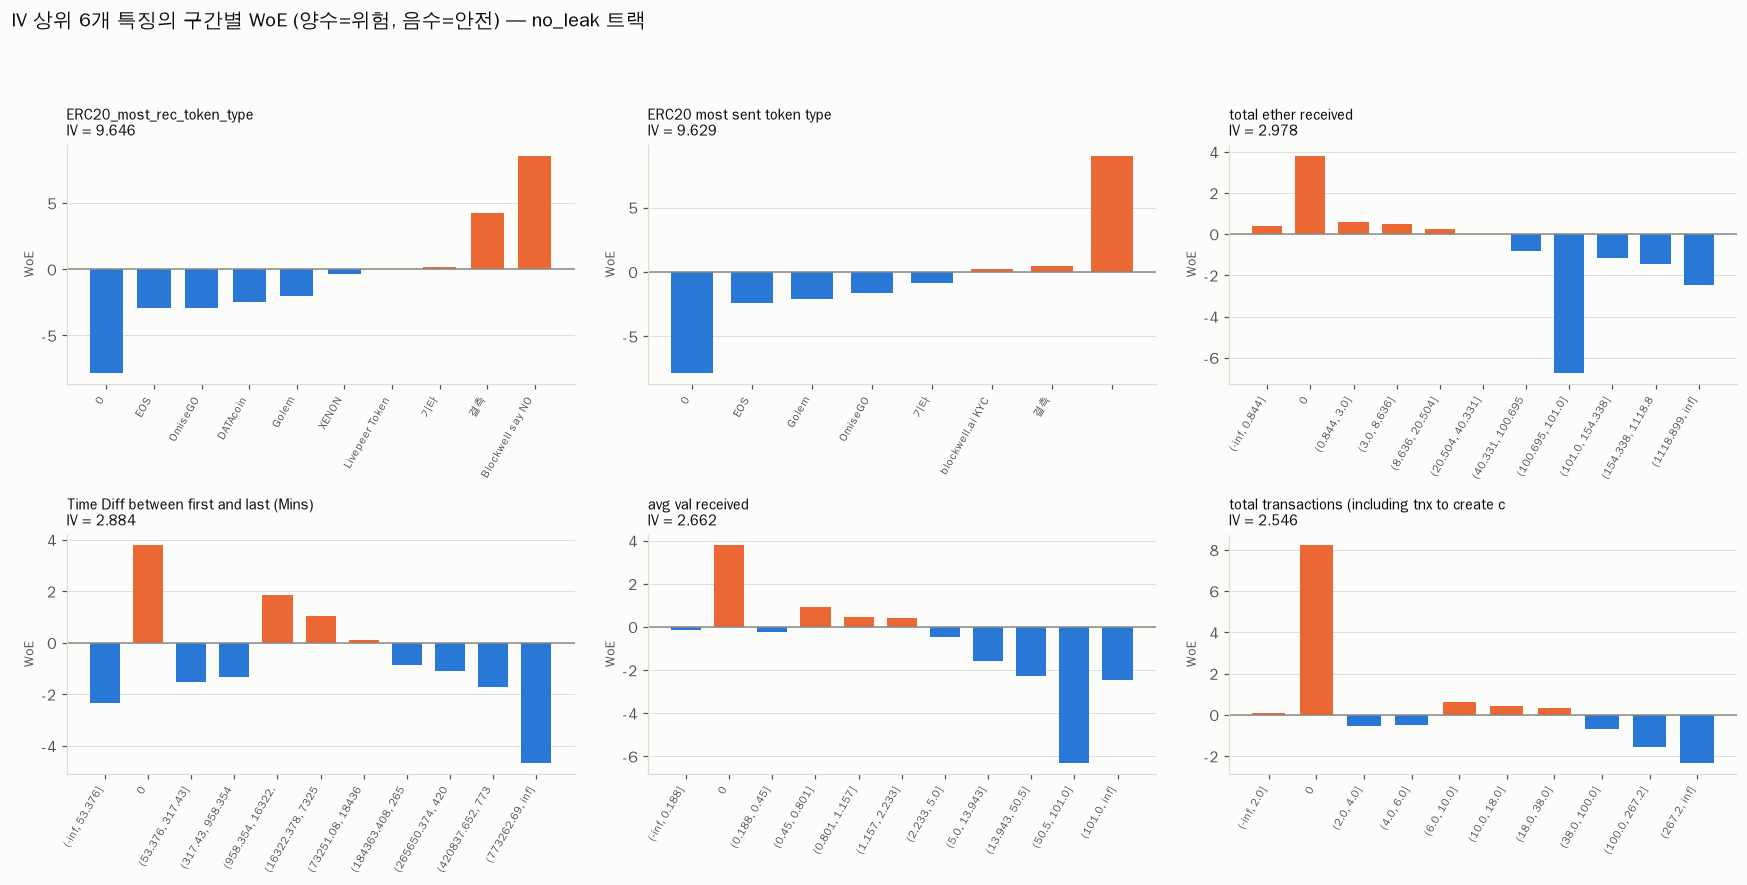

In [13]:
# IV 상위 6개 특징의 구간별 WoE 를 막대로 그린다
top_feature_names = iv_ranking_no_leak.head(6)["특징"].tolist()

figure, axes = plt.subplots(2, 3, figsize=(16, 8))

for axis, feature_name in zip(axes.flatten(), top_feature_names):
    table = woe_encoder_no_leak.binning_tables_[feature_name]

    # WoE 가 양수면 '위험'(주황), 음수면 '안전'(파랑)으로 칠한다.
    # 색만으로 구분하지 않도록 0 기준선과 축 라벨을 함께 둔다.
    bar_colors = [COLOR_FRAUD if woe_value > 0 else COLOR_NORMAL for woe_value in table["WoE"]]

    bar_positions = np.arange(len(table))
    axis.bar(bar_positions, table["WoE"], color=bar_colors, width=0.7)
    axis.axhline(0, color="#8a8a86", linewidth=1.0)   # WoE=0 기준선

    # 구간 이름이 길어서 짧게 줄인다
    short_labels = [str(label)[:16] for label in table["bin"]]
    axis.set_xticks(bar_positions)
    axis.set_xticklabels(short_labels, rotation=60, ha="right", fontsize=7.5)

    iv_value = woe_encoder_no_leak.information_values_[feature_name]
    axis.set_title(f"{feature_name[:45]}\nIV = {iv_value:.3f}", fontsize=9.5, loc="left")
    axis.set_ylabel("WoE", fontsize=8.5)
    axis.grid(axis="x", visible=False)

figure.suptitle(
    "IV 상위 6개 특징의 구간별 WoE (양수=위험, 음수=안전) — no_leak 트랙",
    fontsize=13, x=0.01, ha="left", y=1.0,
)
figure.tight_layout(rect=[0, 0, 1, 0.95])
figure.savefig(config.FIGURES_DIRECTORY / "03_woe_by_bin.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 5. 보고서 저장

In [14]:
# IV 순위표를 reports/iv_ranking.md 로 저장한다
lines = ["# IV(정보가치) 순위표", ""]
lines.append("특징별 **정보가치(IV)** 를 계산해 순위를 매긴 표입니다.")
lines.append("계산식과 기호 설명은 `notebooks/02_woe_iv.ipynb` 또는 `src/woe_iv.py` 를 보세요.")
lines.append("")
lines.append("## IV 해석 기준")
lines.append("")
lines.append("| IV 범위 | 해석 |")
lines.append("|---|---|")
lines.append("| < 0.02 | 거의 쓸모없음 |")
lines.append("| 0.02 ~ 0.1 | 약함 |")
lines.append("| 0.1 ~ 0.3 | 중간 |")
lines.append("| 0.3 ~ 0.5 | 강함 |")
lines.append("| > 0.5 | 매우 강함 — **데이터 누수 의심** |")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## IV 상위 15개 — full 트랙 (누수 포함)")
lines.append("")
lines.append(iv_top15_full.to_markdown(index=False))
lines.append("")
lines.append("## IV 상위 15개 — no_leak 트랙 (누수 최소 차단)")
lines.append("")
lines.append(iv_top15_no_leak.to_markdown(index=False))
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 오염 경로 — 정답이 완벽하게 갈리는 구간")
lines.append("")
lines.append("어떤 구간에 30건 이상이 들어 있는데 사기 비율이 정확히 0% 또는 100% 라면,")
lines.append("그것은 예측이 아니라 **정답이 새는 통로**입니다.")
lines.append("")
lines.append(perfect_bins.head(20).to_markdown(index=False) if len(perfect_bins) else "(없음)")
lines.append("")
lines.append("## 비정상적으로 반복되는 값")
lines.append("")
lines.append("진짜 거래라면 금액이 소수점까지 제각각이어야 합니다.")
lines.append("수백~수천 개 주소가 정확히 같은 금액을 가졌다면 인위적으로 만들어진 데이터일 수 있습니다.")
lines.append("")
lines.append(repeated_values_table.to_markdown(index=False))
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 전체 IV 순위 (no_leak 트랙)")
lines.append("")
lines.append(iv_ranking_no_leak.round(4).to_markdown(index=False))
lines.append("")

output_path = config.REPORTS_DIRECTORY / "iv_ranking.md"
output_path.write_text("\n".join(lines), encoding="utf-8")
print(f"저장 완료: {output_path}")

저장 완료: /home/user/blockchain/reports/iv_ranking.md


---

## 6. 단계 3 요약

**만든 것**

- `src/woe_iv.py` — WoE·IV 를 직접 구현 (fit / transform 구조라 교차검증 안에서 안전하게 쓸 수 있음)
- `src/preprocessing.py` — 두 트랙(full / no_leak)의 모델링 데이터 생성
- `reports/iv_ranking.md` — IV 상위 15개 표 (두 트랙) + 전체 순위
- `reports/figures/03_woe_by_bin.png` — 상위 6개 특징의 구간별 WoE

**핵심 발견**

- 41개 특징이 **전부 IV > 0.5** → 데이터 전체가 오염됨
- 정답이 새는 경로를 **최소 4군데** 특정 (ERC20 결측 / 껍데기 행 / 토큰 이름 / 반복 금액 101.0)
- 그중 2군데는 차단했고, 2군데는 남아 있음 → 성능 숫자를 그대로 믿으면 안 됨

**다음 단계(4)**: 로지스틱회귀(WoE 입력) / LightGBM / 랜덤포레스트를
층화 5-fold 교차검증으로 비교합니다. **두 트랙 각각** 돌려서
누수가 성능을 얼마나 부풀렸는지 숫자로 보여줍니다.

지표는 **AUC · KS · F1(사기 클래스 기준)** 을 씁니다.